In [28]:
from pathlib import Path
import re
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import torch
except ImportError:
    torch = None

pd.set_option("display.max_columns", 100)

In [29]:
user = "jrhowell"

# KOA-style paths
dataset_dir = Path(f"/home/{user}/sadow_koastore/shared/coral_seg/data/")
results_dir = Path(f"/home/{user}/benthic_ecology_group/Jack/coral_seg/results/")

# Folder with checkpoints from one training run
checkpoint_dir = results_dir / "checkpoints_06.01.2026_6"

# Optional: point directly to one or more metrics.csv files if you know them
# Example:
# metrics_csv_paths = [results_dir / "lightning_logs/version_0/metrics.csv"]
metrics_csv_paths = [results_dir / "lightning_logs_06.01.2026_6/version_0/metrics.csv"]

# Local fallback: if running this notebook in the same folder as uploaded .ckpt files
local_checkpoint_dir = Path(".")

In [30]:
def parse_checkpoint_filename(path):
    """
    Extract epoch and val_loss from filenames like:
    coral-segformer-epoch=02-val_loss=0.28.ckpt
    coral-segformer-epoch=02-val_loss=0.28 (2).ckpt
    """
    path = Path(path)
    name = path.name

    epoch_match = re.search(r"epoch=(\d+)", name)
    val_match = re.search(r"val_loss=([0-9]*\.?[0-9]+)", name)

    epoch = int(epoch_match.group(1)) if epoch_match else np.nan
    val_loss = float(val_match.group(1)) if val_match else np.nan

    return {
        "checkpoint_path": str(path),
        "checkpoint_name": name,
        "epoch_from_name": epoch,
        "val_loss_from_name": val_loss,
    }


def checkpoint_table(checkpoint_paths):
    rows = [parse_checkpoint_filename(p) for p in checkpoint_paths]
    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    df = df.sort_values(["epoch_from_name", "checkpoint_name"]).reset_index(drop=True)

    if torch is not None:
        epochs = []
        global_steps = []
        for p in df["checkpoint_path"]:
            try:
                ckpt = torch.load(p, map_location="cpu")
                epochs.append(ckpt.get("epoch", np.nan))
                global_steps.append(ckpt.get("global_step", np.nan))
            except Exception:
                epochs.append(np.nan)
                global_steps.append(np.nan)

        df["epoch_in_ckpt"] = epochs
        df["global_step_in_ckpt"] = global_steps

    return df


def find_metrics_csvs(search_root):
    search_root = Path(search_root)
    patterns = [
        str(search_root / "**" / "metrics.csv"),
        str(search_root / "**" / "csv_logs" / "**" / "metrics.csv"),
        str(search_root / "**" / "lightning_logs" / "**" / "metrics.csv"),
    ]

    paths = []
    for pattern in patterns:
        paths.extend(glob.glob(pattern, recursive=True))

    return sorted(set(paths))


def standardize_metrics_csv(path):
    """
    Read a Lightning metrics.csv and return a long-ish table with columns:
    epoch, step, train_loss, val_loss when available.

    Lightning often logs train_loss and val_loss on different rows, so this
    function keeps rows sorted and does not assume both are on the same row.
    """
    path = Path(path)
    df = pd.read_csv(path)
    df["source_metrics_csv"] = str(path)

    # Make column names easier to search
    lower_cols = {c: c.lower() for c in df.columns}

    # Candidate train/validation loss columns commonly used in Lightning
    train_candidates = [
        c for c in df.columns
        if any(key in c.lower() for key in ["train_loss", "training_loss", "loss/train", "train/loss"])
    ]

    val_candidates = [
        c for c in df.columns
        if any(key in c.lower() for key in ["val_loss", "valid_loss", "validation_loss", "loss/val", "val/loss"])
    ]

    # If your code logs "loss" only during training, include it carefully
    # only if no better train_loss column exists.
    if not train_candidates:
        plain_loss_cols = [c for c in df.columns if c.lower() == "loss"]
        train_candidates.extend(plain_loss_cols)

    out = df.copy()

    if train_candidates:
        out["train_loss_clean"] = out[train_candidates].bfill(axis=1).iloc[:, 0]
    else:
        out["train_loss_clean"] = np.nan

    if val_candidates:
        out["val_loss_clean"] = out[val_candidates].bfill(axis=1).iloc[:, 0]
    else:
        out["val_loss_clean"] = np.nan

    if "epoch" not in out.columns:
        out["epoch"] = np.nan

    if "step" not in out.columns:
        out["step"] = np.arange(len(out))

    return out


def summarize_decreasing(values, label="loss"):
    """
    Simple checks for whether a loss is decreasing.

    This is not a statistical test. It gives practical diagnostics:
    - first value
    - last value
    - percent change
    - fraction of step-to-step changes that decrease
    """
    s = pd.Series(values).dropna().astype(float)

    if len(s) < 2:
        return {
            "label": label,
            "n_points": len(s),
            "first": np.nan if len(s) == 0 else s.iloc[0],
            "last": np.nan if len(s) == 0 else s.iloc[-1],
            "percent_change": np.nan,
            "fraction_steps_decreasing": np.nan,
            "overall_decreasing": False,
            "note": "Need at least 2 points."
        }

    diffs = s.diff().dropna()
    first = s.iloc[0]
    last = s.iloc[-1]

    return {
        "label": label,
        "n_points": len(s),
        "first": first,
        "last": last,
        "percent_change": 100 * (last - first) / first if first != 0 else np.nan,
        "fraction_steps_decreasing": (diffs < 0).mean(),
        "overall_decreasing": last < first,
        "note": "Overall decreased." if last < first else "Overall did not decrease."
    }

In [31]:
# Find checkpoints from the selected folder.
checkpoint_paths = sorted(glob.glob(str(checkpoint_dir / "*.ckpt")))

# Fallback for local/uploaded checkpoints.
if len(checkpoint_paths) == 0:
    checkpoint_paths = sorted(glob.glob(str(local_checkpoint_dir / "*.ckpt")))

ckpt_df = checkpoint_table(checkpoint_paths)
ckpt_df

,checkpoint_path,checkpoint_name,epoch_from_name,val_loss_from_name,epoch_in_ckpt,global_step_in_ckpt
0,/home/jrhowell/benthic_ecology_group/Jack/cora...,coral-segformer-epoch=00-val_loss=0.19.ckpt,0.0,0.19,0,597
1,/home/jrhowell/benthic_ecology_group/Jack/cora...,coral-segformer-epoch=01-val_loss=0.18.ckpt,1.0,0.18,1,1194
2,/home/jrhowell/benthic_ecology_group/Jack/cora...,last.ckpt,NaN,NaN,1,1194


In [32]:
# If you did not manually enter metrics_csv_paths above, search under results_dir.
if not metrics_csv_paths:
    metrics_csv_paths = find_metrics_csvs(results_dir)

print("Found metrics.csv files:")
for p in metrics_csv_paths:
    print(" -", p)

Found metrics.csv files:
 - /home/jrhowell/benthic_ecology_group/Jack/coral_seg/results/lightning_logs_06.01.2026_4/version_0/metrics.csv


In [33]:
metrics_tables = []

for p in metrics_csv_paths:
    try:
        metrics_tables.append(standardize_metrics_csv(p))
    except Exception as e:
        print(f"Could not read {p}: {e}")

if metrics_tables:
    metrics_df = pd.concat(metrics_tables, ignore_index=True)
else:
    metrics_df = pd.DataFrame()

metrics_df.head()

,epoch,lr-AdamW,step,train_loss_epoch,train_loss_step,val_loss,source_metrics_csv,train_loss_clean,val_loss_clean
0,NaN,0.0001,9,NaN,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...,NaN,NaN
1,0.0,NaN,9,NaN,0.674781,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...,0.674781,NaN
2,NaN,0.0001,19,NaN,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...,NaN,NaN
3,0.0,NaN,19,NaN,0.523382,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...,0.523382,NaN
4,NaN,0.0001,29,NaN,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...,NaN,NaN


In [34]:
if len(metrics_df) > 0:
    print("Columns in metrics file(s):")
    print(list(metrics_df.columns))

    display(metrics_df[[
        c for c in ["epoch", "step", "train_loss_clean", "val_loss_clean", "source_metrics_csv"]
        if c in metrics_df.columns
    ]].dropna(how="all").head(20))
else:
    print("No metrics.csv data loaded.")

Columns in metrics file(s):
['epoch', 'lr-AdamW', 'step', 'train_loss_epoch', 'train_loss_step', 'val_loss', 'source_metrics_csv', 'train_loss_clean', 'val_loss_clean']


,epoch,step,train_loss_clean,val_loss_clean,source_metrics_csv
0,NaN,9,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
1,0.0,9,0.674781,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
2,NaN,19,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
3,0.0,19,0.523382,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
4,NaN,29,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
5,0.0,29,0.472203,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
6,NaN,39,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
7,0.0,39,0.330970,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
8,NaN,49,NaN,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...
9,0.0,49,0.380327,NaN,/home/jrhowell/benthic_ecology_group/Jack/cora...


,epoch,train_loss,val_loss
0,0.0,0.267427,0.187891
1,1.0,0.174045,0.179991
2,2.0,0.154439,0.190377
3,3.0,0.142148,0.221610
4,4.0,0.128165,0.207574
5,5.0,0.118422,0.224009
6,6.0,0.115794,0.233544
7,7.0,0.109794,0.232659
8,8.0,0.107146,0.233331
9,9.0,0.103554,0.240311


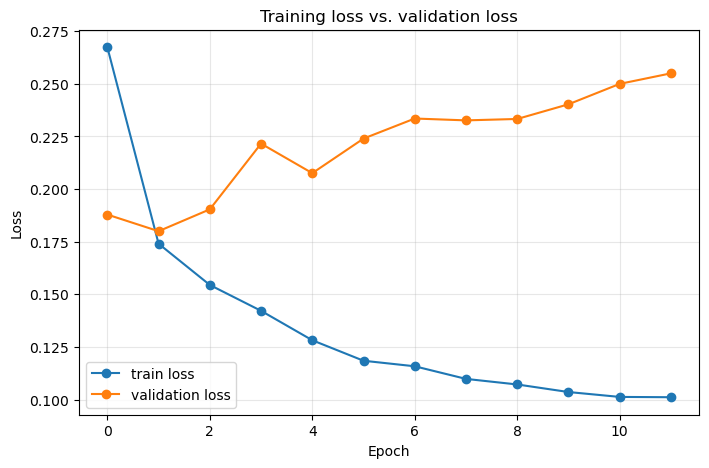

,label,n_points,first,last,percent_change,fraction_steps_decreasing,overall_decreasing,note
0,train_loss,12,0.267427,0.101087,-62.200306,1.000000,True,Overall decreased.
1,val_loss,12,0.187891,0.255022,35.728598,0.272727,False,Overall did not decrease.


In [35]:
if len(metrics_df) > 0:
    # Average training loss by epoch
    train_by_epoch = (
        metrics_df.dropna(subset=["train_loss_clean"])
        .groupby("epoch", as_index=False)["train_loss_clean"]
        .mean()
        .rename(columns={"train_loss_clean": "train_loss"})
    )

    # Average validation loss by epoch in case more than one validation row exists
    val_by_epoch = (
        metrics_df.dropna(subset=["val_loss_clean"])
        .groupby("epoch", as_index=False)["val_loss_clean"]
        .mean()
        .rename(columns={"val_loss_clean": "val_loss"})
    )

    loss_by_epoch = pd.merge(train_by_epoch, val_by_epoch, on="epoch", how="outer").sort_values("epoch")
    display(loss_by_epoch)

    fig, ax = plt.subplots(figsize=(8, 5))

    if loss_by_epoch["train_loss"].notna().any():
        ax.plot(loss_by_epoch["epoch"], loss_by_epoch["train_loss"], marker="o", label="train loss")

    if loss_by_epoch["val_loss"].notna().any():
        ax.plot(loss_by_epoch["epoch"], loss_by_epoch["val_loss"], marker="o", label="validation loss")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training loss vs. validation loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    checks = []
    if loss_by_epoch["train_loss"].notna().any():
        checks.append(summarize_decreasing(loss_by_epoch["train_loss"], label="train_loss"))
    if loss_by_epoch["val_loss"].notna().any():
        checks.append(summarize_decreasing(loss_by_epoch["val_loss"], label="val_loss"))

    display(pd.DataFrame(checks))
else:
    print("No metrics.csv loaded, so full train-vs-validation loss curves cannot be plotted yet.")

In [36]:
if len(ckpt_df) > 0 and len(metrics_df) > 0:
    if "loss_by_epoch" not in globals():
        train_by_epoch = (
            metrics_df.dropna(subset=["train_loss_clean"])
            .groupby("epoch", as_index=False)["train_loss_clean"]
            .mean()
            .rename(columns={"train_loss_clean": "train_loss"})
        )
        val_by_epoch = (
            metrics_df.dropna(subset=["val_loss_clean"])
            .groupby("epoch", as_index=False)["val_loss_clean"]
            .mean()
            .rename(columns={"val_loss_clean": "val_loss"})
        )
        loss_by_epoch = pd.merge(train_by_epoch, val_by_epoch, on="epoch", how="outer").sort_values("epoch")

    compare_df = ckpt_df.merge(
        loss_by_epoch,
        left_on="epoch_from_name",
        right_on="epoch",
        how="left"
    )

    compare_df["val_loss_difference_filename_minus_log"] = (
        compare_df["val_loss_from_name"] - compare_df["val_loss"]
    )

    display(compare_df[[
        "checkpoint_name",
        "epoch_from_name",
        "val_loss_from_name",
        "train_loss",
        "val_loss",
        "val_loss_difference_filename_minus_log"
    ]])
else:
    print("Need both checkpoints and metrics.csv data for this comparison.")

,checkpoint_name,epoch_from_name,val_loss_from_name,train_loss,val_loss,val_loss_difference_filename_minus_log
0,coral-segformer-epoch=00-val_loss=0.19.ckpt,0.0,0.19,0.267427,0.187891,0.002109
1,coral-segformer-epoch=01-val_loss=0.18.ckpt,1.0,0.18,0.174045,0.179991,0.000009
2,last.ckpt,NaN,NaN,NaN,NaN,NaN
